# CV noise floor: how much does pure seed-to-seed scatter explain?

Two open questions from earlier notebooks both come down to the same missing
ingredient: a **noise floor** measured from real data, not just from a
resampling/permutation test on the data itself.

- Notebook 02's `Omega_m` signal is checked against a *permutation* null
  (shuffle which simulation got which `Omega_m`) -- a legitimate test, but
  it doesn't answer "how big is this compared to just rerunning the same
  universe with different noise?"
- Notebook 04's 1P trend test is checked against an *exact permutation*
  null, but at n=4-5 points that null can never produce a small p-value
  even for a real effect -- a fundamentally different, independent check is
  needed to say anything more.

The CAMELS **CV set** answers this directly: every realization uses the
exact same (fiducial) cosmology and feedback parameters -- only the
initial-condition random seed differs. So the *only* thing that can make
the AGN kNN-CDF differ between CV realizations is chance (cosmic variance).
The spread across CV realizations is therefore a direct, physical
measurement of "how much does this statistic wobble for free", to compare
real responses against.

As with every other notebook here: nothing about the CV set's realization
count or directory naming is assumed -- section 1 discovers it.

In [1]:
import sys
sys.path.insert(0, "..")

import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_io import find_snapshots
from src.params import load_cv_params, load_params, load_1p_params, align_to_params
from src.pipeline import run_suite
from src.abundance import remove_abundance
from src.sensitivity import sensitivity_table, infer_layout
from src.onep import infer_1p_parameter_names, mean_cdf_by_step, step_label, fiducial_value, COSMO_ALIASES
from src.cv import per_bin_std, scalar_noise_floor, signal_to_noise

SIM_PATH_CV = config.SIM_PATH_CV
PARAMS_FILE_CV = config.PARAMS_FILE_CV
PARAMS_FILE = config.PARAMS_FILE
PARAMS_FILE_1P = config.PARAMS_FILE_1P
OUTPUT_DIR = config.OUTPUT_DIR

## 1. What's actually on disk?

Lists every CV snapshot found and, if the CV parameter table exists, checks
that it actually holds every column fixed except the seed -- the assumption
the whole rest of this notebook rests on.

In [2]:
files_cv = find_snapshots(SIM_PATH_CV, config.SNAP, prefix="CV_")
print(f"Found {len(files_cv)} CV snapshots at snap={config.SNAP}")

try:
    theta_cv = load_cv_params(PARAMS_FILE_CV)
    print(f"\nCV parameter table: {theta_cv.shape[0]} rows, columns = {list(theta_cv.columns)}")

    non_fixed = [c for c in theta_cv.columns if c != "seed" and theta_cv[c].nunique() > 1]
    if non_fixed:
        print(f"\nWARNING -- these columns are NOT fixed across CV realizations: {non_fixed}")
        print("CV is supposed to hold cosmology/astrophysics fixed; this notebook's")
        print("noise-floor interpretation assumes that. Inspect before trusting the rest.")
    else:
        print("\nEvery column except 'seed' is fixed across CV realizations, as expected.")
except FileNotFoundError:
    print(f"\nNo CV parameter table found at {PARAMS_FILE_CV} -- proceeding without it "
          "(not required for the noise-floor calculation itself, only for this sanity check).")

Found 27 CV snapshots at snap=50

CV parameter table: 27 rows, columns = ['Omega_m', 'sigma_8', 'A_SN1', 'A_AGN1', 'A_SN2', 'A_AGN2', 'seed']

Every column except 'seed' is fixed across CV realizations, as expected.


## 2. Generate fixed-N AGN summaries over the CV set

Same `N_TARGET`/`mass_cut`/`kvals`/`rgrid` as every other fixed-N run here,
read from the LH run's saved `.npz`, so the noise floor lands on the same
scale as everything it will be compared against.

In [3]:
agn_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/agn_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n*.npz"))
assert agn_candidates, f"No LH AGN fixed-N run found in {OUTPUT_DIR} -- run notebook 02 first."
agn_data = np.load(agn_candidates[-1], allow_pickle=True)
N_TARGET = int(agn_data["nbh"][0])
print(f"N_TARGET = {N_TARGET} (from the LH AGN run)")

N_TARGET = 286 (from the LH AGN run)


In [4]:
GENERATE = False

cv_path = f"{OUTPUT_DIR}/cv_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n{N_TARGET}.npz"

if GENERATE:
    result = run_suite(
        n_target=N_TARGET, tracer="luminosity",
        sim_path=SIM_PATH_CV, output_dir=OUTPUT_DIR,
        dir_prefix="CV_",
    )
else:
    data = np.load(cv_path, allow_pickle=True)
    result = {k: data[k] for k in ("sim_ids", "summaries", "nbh", "rgrid", "kvals")}

cv_sim_ids = result["sim_ids"]
cv_summaries = result["summaries"]
cv_rgrid = result["rgrid"]
cv_kvals = result["kvals"]
cv_n_k, cv_n_r = infer_layout(cv_kvals, cv_rgrid)

print(f"{len(cv_sim_ids)} CV realizations retained at N={N_TARGET}, summary shape {cv_summaries.shape}")
print(f"dropped: {len(files_cv) - len(cv_sim_ids)} / {len(files_cv)} (too few eligible AGN at this N)")

27 CV realizations retained at N=286, summary shape (27, 150)
dropped: 0 / 27 (too few eligible AGN at this N)


## 3. The noise floor itself

Scalar noise floor (RMS over bins of per-bin std): 0.01573


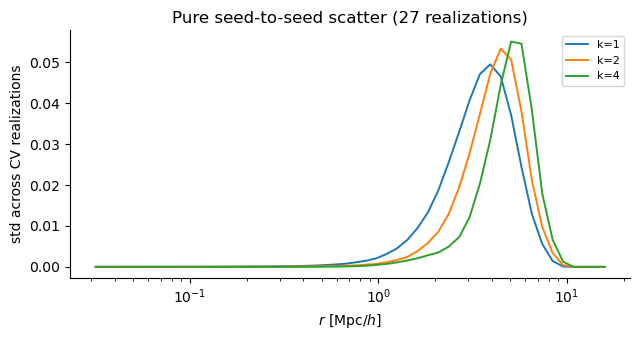

In [5]:
cv_std = per_bin_std(cv_summaries, cv_n_k, cv_n_r)          # (n_k, n_r)
cv_scalar = scalar_noise_floor(cv_summaries)                 # single number

print(f"Scalar noise floor (RMS over bins of per-bin std): {cv_scalar:.5f}")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
for ki in range(cv_n_k):
    ax.plot(cv_rgrid, cv_std[ki], lw=1.4, label=f"k={cv_kvals[ki]}")
ax.set_xscale("log")
ax.set_xlabel(r"$r\ [\mathrm{Mpc}/h]$")
ax.set_ylabel("std across CV realizations")
ax.set_title(f"Pure seed-to-seed scatter ({len(cv_sim_ids)} realizations)")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## 4. Against the LH `Omega_m` signal

Recomputes `Omega_m`'s scale-resolved response from the LH fixed-N run
(same recipe as notebook 02/03: no abundance removal needed at fixed N),
then overlays it on the CV noise band -- a direct, physically-grounded
alternative to the permutation null already used for this signal.

In [6]:
theta_all = load_params(PARAMS_FILE)
agn_theta = align_to_params(agn_data["sim_ids"], theta_all)
agn_residuals = agn_data["summaries"] - agn_data["summaries"].mean(axis=0)
agn_n_k, agn_n_r = infer_layout(agn_data["kvals"], agn_data["rgrid"])

assert agn_n_k == cv_n_k and len(agn_data["rgrid"]) == len(cv_rgrid), (
    "LH and CV runs used different kvals/rgrid -- not directly comparable. "
    "Check that neither notebook overrode config.KVALS/config.RGRID."
)

table_omega_m = sensitivity_table(
    agn_residuals, agn_theta,
    n_k=agn_n_k, rgrid=agn_data["rgrid"], kvals=agn_data["kvals"],
    params=["Omega_m"], n_boot=2000, n_null=2000,
)

r_omega_m = table_omega_m["Omega_m"]["R_scalar"]
print(f"R(Omega_m)          = {r_omega_m:.5f}")
print(f"CV scalar noise floor = {cv_scalar:.5f}")
print(f"Ratio (S/N)          = {r_omega_m / cv_scalar:.2f}")

R(Omega_m)          = 0.02068
CV scalar noise floor = 0.01573
Ratio (S/N)          = 1.32


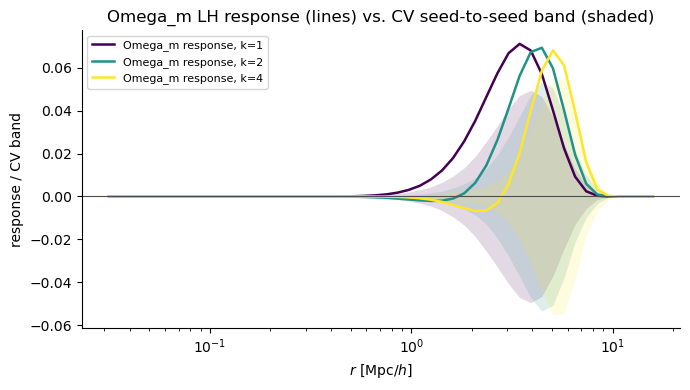

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
cmap = plt.get_cmap("viridis")

obs = table_omega_m["Omega_m"]["obs"]
for ki in range(agn_n_k):
    colour = cmap(ki / max(agn_n_k - 1, 1))
    ax.plot(agn_data["rgrid"], obs[ki], color=colour, lw=1.8, label=f"Omega_m response, k={agn_data['kvals'][ki]}")
    ax.fill_between(cv_rgrid, -cv_std[ki], cv_std[ki], color=colour, alpha=0.15, lw=0)

ax.axhline(0, color="0.3", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"$r\ [\mathrm{Mpc}/h]$")
ax.set_ylabel(r"response / CV band")
ax.set_title("Omega_m LH response (lines) vs. CV seed-to-seed band (shaded)")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## 5. Against the 1P trend-test ranking

For each 1P parameter, compares the *range* it sweeps out at the same probe
bin used in notebook 04 (max minus min of the mean CDF across that
parameter's own steps) against the CV noise floor at that same bin --
an independent second opinion alongside the exact-permutation ranking
notebook 04 already computed. This is a simple ratio, not a p-value (see
`cv.signal_to_noise`'s docstring): read it as "how many noise-widths", not
as a probability.

In [8]:
onep_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/1p_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n*.npz"))
assert onep_candidates, f"No 1P run found in {OUTPUT_DIR} -- run notebook 04 first."
onep_data = np.load(onep_candidates[-1], allow_pickle=True)

onep_sim_ids = onep_data["sim_ids"]
onep_summaries = onep_data["summaries"]
onep_rgrid = onep_data["rgrid"]
onep_kvals = onep_data["kvals"]
onep_n_k, onep_n_r = infer_layout(onep_kvals, onep_rgrid)

assert onep_n_k == cv_n_k and len(onep_rgrid) == len(cv_rgrid), (
    "1P and CV runs used different kvals/rgrid -- not directly comparable."
)

theta_1p_all = load_1p_params(PARAMS_FILE_1P)
mapping, ambiguous = infer_1p_parameter_names(theta_1p_all)
assert not ambiguous, f"Resolve ambiguous 1P groups first: {ambiguous}"

probe_r = np.argmin(np.abs(onep_rgrid - 4.0))  # same fixed probe bin as notebook 04
cv_std_probe = cv_std[0, probe_r]  # k=1, same as notebook 04's trend test

rows = []
for pidx, name in sorted(mapping.items()):
    steps, mean_cdfs = mean_cdf_by_step(onep_summaries, onep_sim_ids, param_index=pidx, n_k=onep_n_k, n_r=onep_n_r)
    if len(steps) < 2:
        continue
    response_at_probe = mean_cdfs[:, 0, probe_r]
    sweep_range = response_at_probe.max() - response_at_probe.min()
    rows.append({
        "parameter": name,
        "group": "cosmological" if name in COSMO_ALIASES else "astrophysics",
        "n_steps": len(steps),
        "sweep_range": sweep_range,
        "cv_signal_to_noise": signal_to_noise(sweep_range, cv_std_probe),
    })

cv_ranked = pd.DataFrame(rows).sort_values("cv_signal_to_noise", ascending=False).reset_index(drop=True)
cv_ranked

,parameter,group,n_steps,sweep_range,cv_signal_to_noise
0,n_s,astrophysics,5,0.071154,1.436357
1,Omega0,cosmological,4,0.045132,0.911065
2,IMFslope,astrophysics,5,0.041916,0.846136
3,WindEnergyReductionMetallicity,astrophysics,5,0.041680,0.841373
4,QuasarThreshold,astrophysics,5,0.039031,0.787896
5,BlackHoleAccretionFactor,astrophysics,5,0.035895,0.724584
6,HubbleParam,astrophysics,5,0.034371,0.693824
7,OmegaBaryon,astrophysics,5,0.033007,0.666295
8,MinWindVel,astrophysics,5,0.032505,0.656160
9,MaxSfrTimescale,astrophysics,5,0.032380,0.653646


## Reading this

Two independent checks, two different weaknesses -- read them together, not
either alone:

- **The exact-permutation ranking (notebook 04)** has a rigorous null
  distribution, but at n=4-5 points it can never reach a small p-value even
  for a real effect (see notebook 04's "Reading this").
- **The CV signal-to-noise ranking (here)** doesn't have that ceiling --
  it's a direct physical scatter measurement -- but it's a ratio, not a
  calibrated p-value, and it doesn't account for its own uncertainty (the
  CV std is itself estimated from a finite ~`len(cv_sim_ids)` realizations,
  so it has its own sampling noise of roughly `1/sqrt(2*(n-1))` relative --
  about 14% at n=27).

If the two rankings broadly agree on which astrophysics parameters look
most promising, that agreement is worth more than either check alone. If
`Omega_m`'s CV-based S/N (section 4) comes out comfortably above 1 while its
1P permutation q-value doesn't clear significance, that's the clearest
demonstration in this whole pipeline that the 1P trend test's small-n
limitation -- not a weak or absent `Omega_m` signal -- is what's holding
notebook 04 back.